# Scikit-Fuzzy

## Ejercicio 1: Aire Acondicionado. 

Ud. ha sido contratado por IPD-Electrónics para trabajar en su marca TEL-Air que comercializará equipos de aire acondicionado. Estos dispositivos climatizan ambientes interiores en el rango entre $17ºC$ a $30ºC$, lanzando aire frio o aire caliente dependiendo de las instrucciones que el usuario le entregue, hasta llegar a la temperatura deseada. Así:

* Para climatizar utilizando el modo _calor_, el aire acondicionado lanza aire caliente constante, a unos $42ºC$, hasta llegar a la temperatura deseada. 
* Para climatizar utilizando el modo _frío_, el aire acondicionado lanza aire fresco constante, a unos $13ºC$, hasta llegar a la temperatura deseada.
* Para mantener el clima actual del ambiente se utiliza el modo _stand by_, que provee de circulación del aire sin modificar la variación normal de la temperatura.
* Para climatizar automáticamente se utiliza el modo _auto_, el cual se encarga de escoger el modo del aire acondicionado, y el nivel de velocidad utilizado.

El aire es lanzado por los dispositivos en tres posibles velocidades: baja, media o alta. Estas velocidades modifican la temperatura, según el modo de aire y las características de la zona climatizada, en los rangos (en $\frac{ºC}{\text{min}}$) $[0.1, 0.7]$, $[0.5, 1.2]$ y $[0.8, 1.9]$, respectivamente. Considere que si está en modo _stand by_ estas variaciones se darán para acercarse a la temperatura del exterior.  

Para controlar la temperatura del ambiente, los dispositivos cuentan con un termostato que les indica la temperatura actual de la zona climatizado.

Considere que para limitar el consumo energético, el modo _auto_ define las siguientes reglas bases:
* Si la diferencia de temperatura es negativa, debe utilizar modo calor.
* Si la diferencia de temperatura es positiva, debe utilizar modo frío.
* Si no hay diferencia de temperatura, debe utilizar el modo stand by.
* Si se encuentra cercano o en la temperatura deseada, utilizar el modo velocidad baja.
* Si se encuentra muy alejado en la tempratura, debe utilizar el modo de velocidad alta. 

Y que además, utilizando el historico de temperatura actual y de destino, reflejado en las configuraciones manuales, se ha determinado qué:
* La temperatura puede ser catalogada como fría si está bajo el umbral de los 15ºC.
* La temperatura puede ser catalogada como fresca si está en el rango de los 12.5ºC a los 20ºC.
* La temperatura puede ser catalogada como ambiente entre los 18ºC a los 25ºC.
* La temperatura puede ser catalogada como calurosa sobre el rango de los 23ºC.

Y como es un sistema basado en la percepción y el comfort humano, se definen las siguientes reglas básicas:
* Si la temperatura es fría, el aire debe utilizar modo calor. 
* Si la temperatura es calurosa, el aire debe utilizar modo frío.

1. Genere un sistema de inferencia difusa que permita para un instante determinado, utilizando el modo _auto_, determinar el modo de funcion del dispositivo y la velocidad con la cual lanza el aire. Determine claramente los antecendentes y los consecuentes del sistema, funciones de membresía y las reglas de inferencia difusa del sistema.

In [1]:
# Incluir librerías
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [2]:
# Variable de Entradas o Antecedentes
dif = ctrl.Antecedent(np.arange(-10, 10, 0.1), 'dif') # negativa, cercana, positiva
temp = ctrl.Antecedent(np.arange(0, 40, 0.1), 'temp') # fría, fresca, ambiente, calurosa

#Variables de salida o Consecuentes
modo = ctrl.Consequent(np.arange(10, 45, 0.1), 'modo') # frio, standby, calor
vel = ctrl.Consequent(np.arange(0.1, 2.0, 0.1), 'vel') # baja, media, alta

/home/polivares/mambaforge/envs/IPD434/lib/python3.11/site-packages/skfuzzy/control/fuzzyvariable.py:122: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


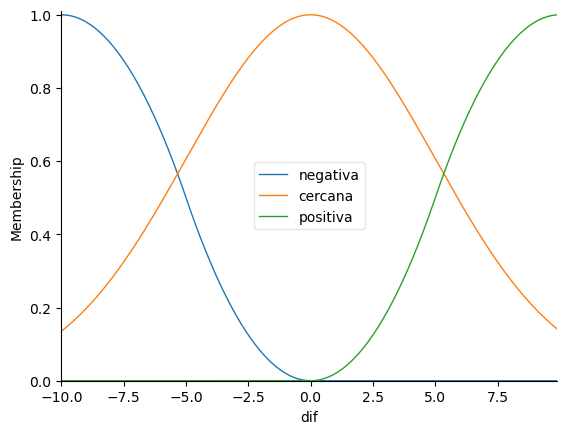

In [3]:
# Funciones de membresía
dif['negativa'] = fuzz.zmf(dif.universe, -10, 0)
dif['cercana'] = fuzz.gaussmf(dif.universe, 0, 5)
dif['positiva'] = fuzz.smf(dif.universe, 0, 10)
dif.view()

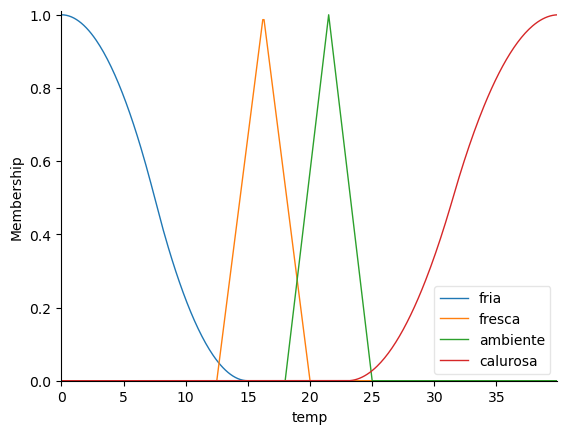

In [4]:
temp['fria'] = fuzz.zmf(temp.universe, 0, 15)
temp['fresca'] = fuzz.trimf(temp.universe, [12.5, 16.25, 20])
temp['ambiente'] = fuzz.trimf(temp.universe, [18, 21.5, 25])
temp['calurosa'] = fuzz.smf(temp.universe, 23, 40)

temp.view()

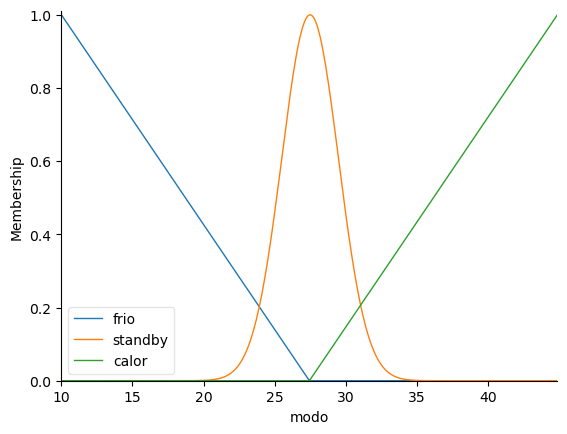

In [5]:
modo_names=['frio', 'standby', 'calor']
modo.automf(names=modo_names)
modo['standby'] = fuzz.gaussmf(modo.universe, 13 + (42-13)/2, 2)
modo.view()

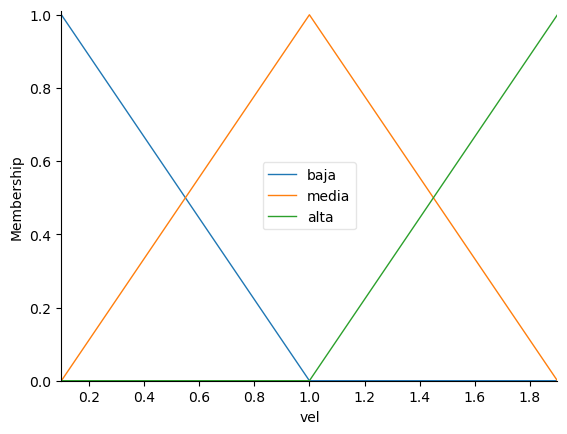

In [6]:
vel_names = ['baja', 'media', 'alta']

vel.automf(names=vel_names) 
vel.view()

Considere que para limitar el consumo energético, el modo _auto_ define las siguientes reglas bases:
* Si la diferencia de temperatura es negativa, debe utilizar modo calor.
* Si la diferencia de temperatura es positiva, debe utilizar modo frío.
* Si no hay diferencia de temperatura, debe utilizar el modo stand by.
* Si se encuentra cercano o en la temperatura deseada, utilizar el modo velocidad baja.
* Si se encuentra muy alejado en la tempratura, debe utilizar el modo de velocidad alta. 

Y que además, utilizando el historico de temperatura actual y de destino, reflejado en las configuraciones manuales, se ha determinado qué:
* La temperatura puede ser catalogada como fría si está bajo el umbral de los 15ºC.
* La temperatura puede ser catalogada como fresca si está en el rango de los 12.5ºC a los 20ºC.
* La temperatura puede ser catalogada como ambiente entre los 18ºC a los 25ºC.
* La temperatura puede ser catalogada como calurosa sobre el rango de los 23ºC.

Y como es un sistema basado en la percepción y el comfort humano, se definen las siguientes reglas básicas:
* Si la temperatura es fría, el aire debe utilizar modo calor. 
* Si la temperatura es calurosa, el aire debe utilizar modo frío.

1. Genere un sistema de inferencia difusa que permita para un instante determinado, utilizando el modo _auto_, determinar el modo de funcion del dispositivo y la velocidad con la cual lanza el aire. Determine claramente los antecendentes y los consecuentes del sistema, funciones de membresía y las reglas de inferencia difusa del sistema.

In [7]:
# Cada regla relaciona antecedentes con consecuentes. Los resuelve segun su valor de la función de membresía.
regla1 = ctrl.Rule(dif['negativa'], modo['calor'])
regla2 = ctrl.Rule(dif['positiva'], modo['frio'])
regla3 = ctrl.Rule(dif['cercana'], modo['standby'])
regla4 = ctrl.Rule(dif['cercana'], vel['baja'])
regla5 = ctrl.Rule(dif['negativa'] | dif['positiva'], vel['alta'])
regla6 = ctrl.Rule(temp['fria'], modo['calor'])
regla7 = ctrl.Rule(temp['calurosa'], modo['frio'])

In [8]:
#Creamos un Systema de Control Difuso, el cual combina todas las reglas creadas.
control_aire = ctrl.ControlSystem([regla1, regla2, regla3, regla4, regla5, regla6, regla7])

In [9]:
# Cálculo previo de dif temperatura
t_solicitada = 30
t_actual = 25
dif_t = t_actual - t_solicitada

# Simulación
aire_funcionando = ctrl.ControlSystemSimulation(control_aire)

aire_funcionando.input['dif'] = dif_t
aire_funcionando.input['temp'] = t_actual
aire_funcionando.compute()

In [10]:
print("Valor de modo", aire_funcionando.output['modo'], "Valor de velocidad", aire_funcionando.output['vel'])

Valor de modo 33.705461052662585 Valor de velocidad 0.9583504886793422


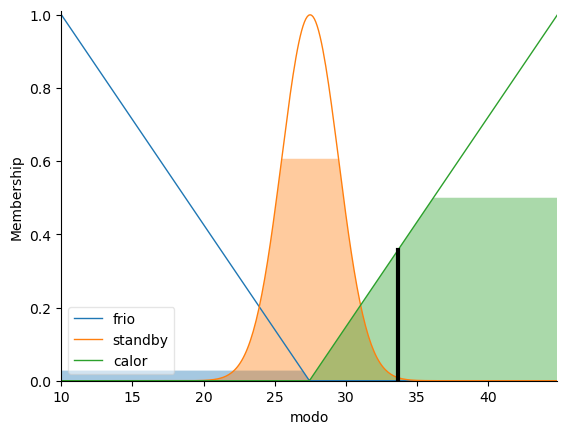

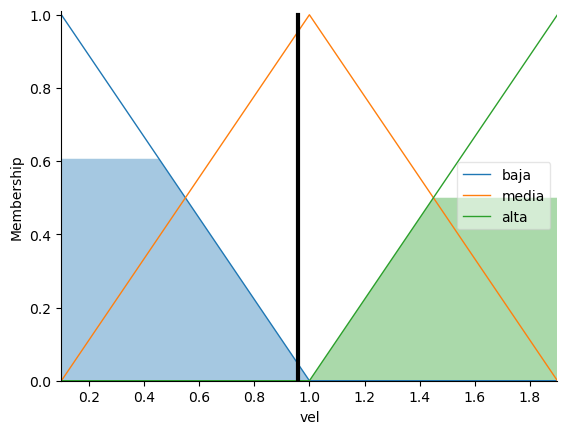

In [11]:
modo.view(sim=aire_funcionando)
vel.view(sim=aire_funcionando)

2. Simule un sistema de control difuso, que muestre como funcionaría el dispositivo durante 15 minutos, considerando una actualización de las condiciones cada 30 segundos.

In [14]:
for i in np.arange(0, 15, 0.5):
    if dif_t > 0:
        t_actual -= aire_funcionando.output['vel']/2
    else:
        t_actual += aire_funcionando.output['vel']/2
    
    dif_t = t_actual - t_solicitada
    aire_funcionando.input['dif'] = dif_t
    aire_funcionando.input['temp'] = t_actual
    aire_funcionando.compute()
    
    print("Valor de modo", aire_funcionando.output['modo'], "Valor de velocidad", aire_funcionando.output['vel'])

Valor de modo 32.67428313979734 Valor de velocidad 0.8942750808001421
Valor de modo 31.602431791149854 Valor de velocidad 0.8322911353837997
Valor de modo 30.515655552828484 Valor de velocidad 0.7733822604800953
Valor de modo 29.438380984075238 Valor de velocidad 0.7181827606554391
Valor de modo 28.39879567252716 Valor de velocidad 0.6671481566489219
Valor de modo 27.430418969482744 Valor de velocidad 0.6206452243151155
Valor de modo 26.551503049549268 Valor de velocidad 0.5788137130650938
Valor de modo 25.77063156805724 Valor de velocidad 0.5416982232953773
Valor de modo 25.088845815776388 Valor de velocidad 0.5092792438482859
Valor de modo 24.50269244778497 Valor de velocidad 0.4815592300214685
Valor de modo 24.002469072615302 Valor de velocidad 0.45815619840959043
Valor de modo 23.580110558229954 Valor de velocidad 0.4390503361750305
Valor de modo 23.225443640756364 Valor de velocidad 0.42398808604796806
Valor de modo 22.92915047555891 Valor de velocidad 0.41271687307758226
Valor de

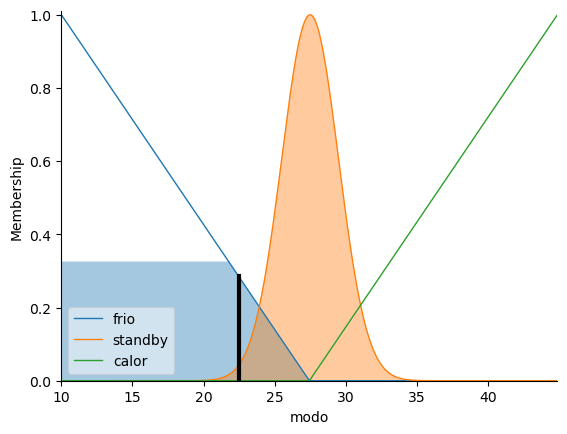

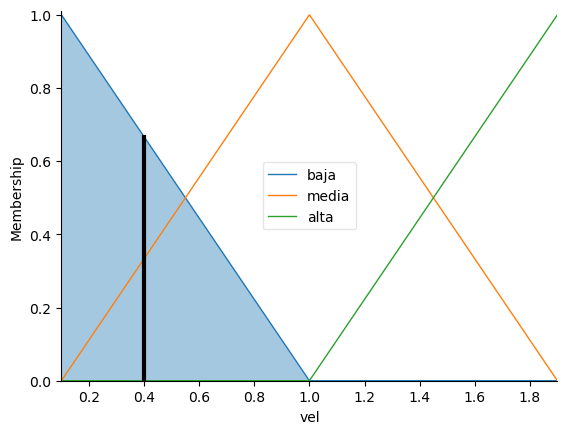

In [15]:
modo.view(sim=aire_funcionando)
vel.view(sim=aire_funcionando)